In [1]:
#!/usr/bin/env python3

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow_model_optimization.quantization.keras import (
    quantize_annotate_layer,
    quantize_annotate_model,
    quantize_apply,
    quantize_scope,
)

import pandas as pd
from configs.configs import FlexibleQuantizeConfig
import numpy as np

In [2]:
# Load the mnist dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize the data to a range of 0 to 1
x_train = x_train / 255.0
x_test = x_test / 255.0

# Convert the labels to one-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [3]:
# Build a simple model with both Dense layers quantized as defined in the config
layer_1 = Flatten(input_shape=(28, 28), name="input")
layer_2 = quantize_annotate_layer(
    Dense(128, activation="relu", name="hidden"),
    FlexibleQuantizeConfig(bits=6, alpha=1),
)
layer_3 = quantize_annotate_layer(
    Dense(10, activation="softmax", name="output"),
    FlexibleQuantizeConfig(bits=6, alpha=1),
)
model = quantize_annotate_model(Sequential([layer_1, layer_2, layer_3]))

with quantize_scope({"FlexibleQuantizeConfig": FlexibleQuantizeConfig}):
    quant_aware_model = quantize_apply(model)
quant_aware_model.summary()

quant_aware_model.compile(
    optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
)


Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
quantize_layer (QuantizeLaye (None, 28, 28)            3         
_________________________________________________________________
quant_input (QuantizeWrapper (None, 784)               1         
_________________________________________________________________
quant_hidden (QuantizeWrappe (None, 128)               100503    
_________________________________________________________________
quant_output (QuantizeWrappe (None, 10)                1313      
Total params: 101,820
Trainable params: 101,814
Non-trainable params: 6
_________________________________________________________________


In [4]:
class VariableHistoryCallback(tf.keras.callbacks.Callback):
    def __init__(self, variable):
        super(VariableHistoryCallback, self).__init__()
        self.variable = variable
        self.variable_values = []

    def on_epoch_end(self, epoch, logs=None):
        # Record the variable's value at the end of each epoch
        self.variable_values.append(self.variable.numpy().flatten())

    def get_history(self):
        # Convert the list of values into a DataFrame
        history_df = pd.DataFrame(self.variable_values)
        history_df.columns = [self.variable.name + str(column_name) for column_name in history_df.columns]
        # Optionally, add epoch number as an index
        history_df.index.name = 'epoch'
        return history_df

vars = quant_aware_model.variables
var_names = [v.name for v in vars]
# print(*var_names)
callbacks = [VariableHistoryCallback(v) for v in vars if ("quant_hidden/kernel_cluster_centers" in v.name) or ("quant_hidden/kernel_cluster_limits" in v.name)]

hist = quant_aware_model.fit(
    x_train,
    y_train,
    epochs=3,
    batch_size=32,
    validation_data=(x_test, y_test),
    callbacks=[callbacks],
)

Epoch 1/3
1875/1875 [==============================] - 10s 5ms/step - loss: 1.7426 - accuracy: 0.4674 - val_loss: 1.7334 - val_accuracy: 0.3772
Epoch 2/3
1875/1875 [==============================] - 9s 5ms/step - loss: 2.0873 - accuracy: 0.1940 - val_loss: 2.2556 - val_accuracy: 0.1427
Epoch 3/3
1875/1875 [==============================] - 9s 5ms/step - loss: 2.2770 - accuracy: 0.1254 - val_loss: 2.2873 - val_accuracy: 0.1148


In [5]:
callbacks[0].get_history()

,quant_hidden/kernel_cluster_centers:00,quant_hidden/kernel_cluster_centers:01,quant_hidden/kernel_cluster_centers:02,quant_hidden/kernel_cluster_centers:03,quant_hidden/kernel_cluster_centers:04,quant_hidden/kernel_cluster_centers:05
epoch,,,,,,
0,-0.833333,-0.5,-0.166667,0.166667,0.5,0.833333
1,-0.833333,-0.5,-0.166667,0.166667,0.5,0.833333
2,-0.833333,-0.5,-0.166667,0.166667,0.5,0.833333


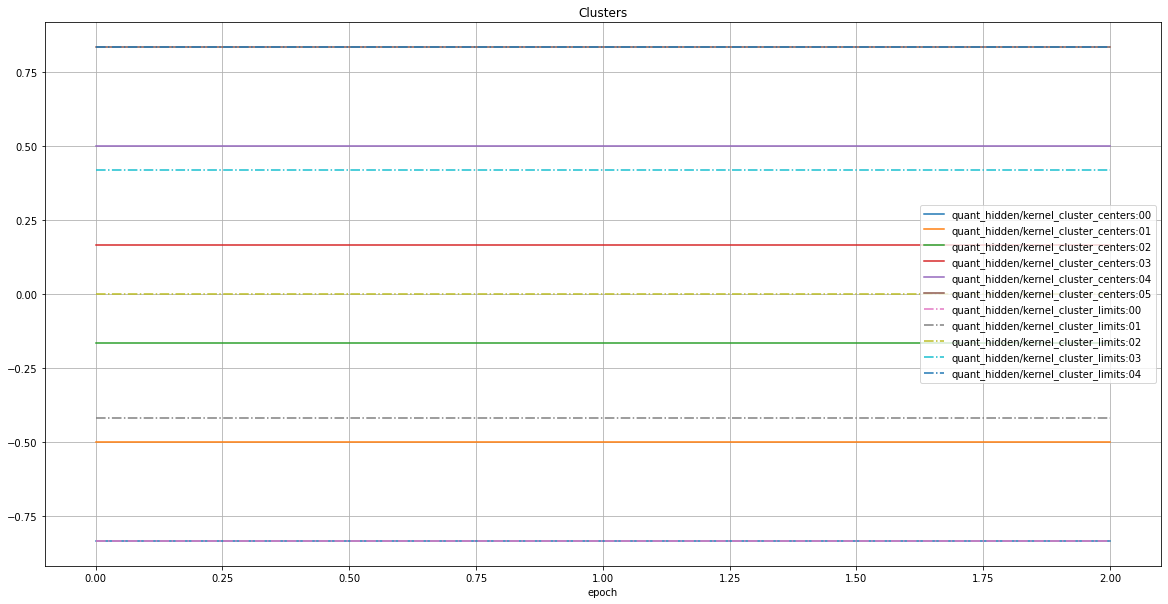

In [6]:
fig, ax = plt.subplots(figsize=(20, 10))  # Create a single figure and axis

for callback in callbacks:
    var_name = callback.variable.name
    history_df = callback.get_history()  # Get the history as a DataFrame
    linestyle="-"
    if "limits" in var_name:
        linestyle="-."
    
    # Plot each variable's history on the same axis
    history_df.plot(ax=ax, grid=True, title="Clusters", linestyle=linestyle)

quant_hidden/kernel_cluster_centers:0
quant_hidden/kernel_cluster_limits:0
313/313 [==============================] - 1s 2ms/step - loss: 2.2873 - accuracy: 0.1148


[2.287257671356201, 0.11479999870061874]

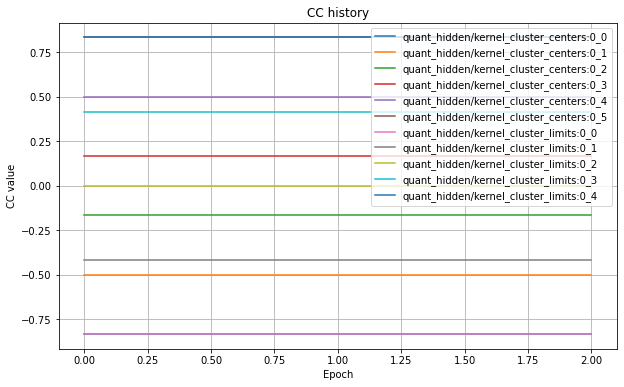

In [7]:
# After fitting the model
plt.figure(figsize=(10, 6))
for callback in callbacks:
    print(callback.variable.name)

    # Get history of variable values
    history = callback.get_history()

    # Convert list of arrays to a 3D numpy array (epochs, clusters, 1) -> (epochs, clusters)
    history_np = np.array(history).squeeze()  # Remove singleton dimension

    # Plot the evolution of each cluster over epochs
    epochs = range(history_np.shape[0])
    num_clusters = history_np.shape[1]

    for cluster_idx in range(num_clusters):
        cluster_values = history_np[:, cluster_idx]
        plt.plot(epochs, cluster_values, label=f"{callback.variable.name}" + "_" + str(cluster_idx))

plt.title("CC history")
plt.xlabel("Epoch")
plt.ylabel("CC value")
plt.grid(which="both")
plt.legend(loc='upper right', bbox_to_anchor=(1, 1))
plt.savefig("alpha_history_2.png")

# Evaluate the model
quant_aware_model.evaluate(x_test, y_test)